# PINN: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das PINN lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[theta, v0, hs, t]`.
- Im Training wird jede vorausgesagte Trajektorie klassifiziert.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken.



In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [35]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25 * hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g / (2 * (l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
        x = vx * t; y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise:
            df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2 * v0 * np.sin(theta) / g
            t_vals = np.linspace(0, T, 50)
            x, y = self.wurftrajektorien(theta, v0, t_vals)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x, y, t_vals):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [36]:
class FreeThrowPINNModel(nn.Module):
    def __init__(self, hidden_dim=64, n_classes=3):
        super().__init__()
        # shared feature extractor
        self.feature_net = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        # head for trajectory (x, y)
        self.xy_head = nn.Linear(hidden_dim, 2)
        # head for classification
        self.class_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, theta, v0, hs, t):
        # ensure (batch, 1) shapes
        if theta.dim() == 1:
            theta = theta.unsqueeze(1)
        if v0.dim() == 1:
            v0 = v0.unsqueeze(1)
        if hs.dim() == 1:
            hs = hs.unsqueeze(1)
        if t.dim() == 1:
            t = t.unsqueeze(1)

        inp = torch.cat([theta, v0, hs, t], dim=1)  # (batch, 4)

        h = self.feature_net(inp)  # (batch, hidden_dim)

        xy = self.xy_head(h)  # (batch, 2)
        x_pred = xy[:, 0:1]
        y_pred = xy[:, 1:2]

        logits = self.class_head(h)  # (batch, n_classes)

        # return both trajectory and class logits
        return x_pred, y_pred, logits


def df_to_tensors(df, hs_val=2.13, device='cpu'):
    d = df.copy()
    if 't' not in d.columns:
        d['vx'] = d['v0'] * np.cos(d['theta']).astype(float)
        d['vx'] = d['vx'].replace(0, 1e-8)
        d['t'] = d['x']/d['vx']
    d['t'] = d['t'].clip(lower=0.0)
    d['hs'] = hs_val
    d = d.dropna(subset=['theta','v0','t','x','y','label','wurf_id'])
    theta = torch.tensor(d['theta'].values, dtype=torch.float32, device=device).unsqueeze(1)
    v0    = torch.tensor(d['v0'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    hs    = torch.tensor(d['hs'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    t     = torch.tensor(d['t'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    x     = torch.tensor(d['x'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    y     = torch.tensor(d['y'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    return theta, v0, hs, t, x, y, d

In [37]:
def physics_residuals(model, theta, v0, hs, t, g=9.807):
    # t for autograd (separate leaf tensor)
    t_req = t.clone().detach().requires_grad_(True)
    th = theta.detach()
    v = v0.detach()
    h = hs.detach()

    # model now returns (x_pred, y_pred, logits)
    x_pred, y_pred, _ = model(th, v, h, t_req)

    dx_dt = torch.autograd.grad(
        x_pred, t_req, grad_outputs=torch.ones_like(x_pred), create_graph=True
    )[0]
    dy_dt = torch.autograd.grad(
        y_pred, t_req, grad_outputs=torch.ones_like(y_pred), create_graph=True
    )[0]

    return dx_dt - v * torch.cos(th), dy_dt - (v * torch.sin(th) - g * t_req)


In [38]:
def train_pinn(
    model,
    df_train,  # nur 1..30
    n_epochs=200,
    batch_size=1024,
    lr=1e-3,
    lambda_data=1.0,
    lambda_phys=1.0,
    lambda_cls=1.0,          # <--- NEW: Gewichtung für Klassifikations-Loss
    n_collocation_per_sample=5,
    df_for_tmax=None,        # voller 1..50-DF
    tmax_by_wurf=None,       # alternativ dict{wurf_id: t_max}
    device="cpu",
):
    device = torch.device(device)

    # --- Tensors für Trainingsdaten (1..30) ---
    theta, v0, hs, t, x_true, y_true, dproc = df_to_tensors(
        df_train, hs_val=2.13, device=device
    )

    # Klassifikationslabels pro Datenpunkt (alle Punkte eines Wurfs haben gleiche label)
    y_class = torch.tensor(
        dproc["label"].values, dtype=torch.long, device=device
    )

    # --- t_max je Wurf bestimmen (UNSKALIERT) ---
    if tmax_by_wurf is None:
        src_df = df_for_tmax if df_for_tmax is not None else df_train
        gb = src_df.groupby("wurf_id", sort=False)["t"].max()
        tmax_series = df_train["wurf_id"].map(gb)
    else:
        tmax_series = df_train["wurf_id"].map(tmax_by_wurf)

    if tmax_series.isna().any():
        missing = df_train.loc[tmax_series.isna(), "wurf_id"].unique().tolist()
        raise ValueError(
            f"Für folgende wurf_id fehlen t_max-Werte in df_for_tmax/tmax_by_wurf: {missing}. "
            "Stelle sicher, dass df_for_tmax alle im Training vorkommenden wurf_id enthält "
            "und die Datentypen identisch sind."
        )

    # In Tensor umwandeln (unskaliert)
    tmax_unscaled = torch.tensor(
        tmax_series.to_numpy(), dtype=t.dtype, device=device
    )

    # Optional: t-Skalierung aus dproc übernehmen
    t_mu = dproc.get("t_mu", None) if isinstance(dproc, dict) else None
    t_std = dproc.get("t_std", None) if isinstance(dproc, dict) else None

    # DataLoader inkl. t_max und Klassifikation
    ds = TensorDataset(theta, v0, hs, t, x_true, y_true, tmax_unscaled, y_class)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    ce  = nn.CrossEntropyLoss()

    hist = {"loss": [], "data_loss": [], "phys_loss": [], "cls_loss": []}

    for ep in range(1, n_epochs + 1):
        ep_loss = ep_data = ep_phys = ep_cls = 0.0
        N = 0
        model.train()

        for batch in dl:
            (
                b_theta,
                b_v0,
                b_hs,
                b_t,
                b_x,
                b_y,
                b_tmax_unscaled,
                b_yc,
            ) = [bi.to(device) for bi in batch]

            opt.zero_grad()

            # --- Daten-Loss ---
            b_t = b_t.clone().detach().requires_grad_(True)
            # Modell gibt (x_pred, y_pred, logits) zurück
            x_pred, y_pred, logits = model(b_theta, b_v0, b_hs, b_t)
            data_loss = mse(x_pred, b_x) + mse(y_pred, b_y)

            # --- Physik-Loss: Datenpunkte ---
            try:
                rx_d, ry_d = physics_residuals(model, b_theta, b_v0, b_hs, b_t)
                phys_data = rx_d.pow(2).mean() + ry_d.pow(2).mean()
            except RuntimeError:
                phys_data = torch.tensor(0.0, device=device)

            # --- Physik-Loss: Collocation bis t_max ---
            K = int(n_collocation_per_sample)
            if K > 0:
                theta_col = b_theta.repeat_interleave(K)
                v0_col    = b_v0.repeat_interleave(K)
                hs_col    = b_hs.repeat_interleave(K)

                tmax_col_unscaled = b_tmax_unscaled.repeat_interleave(K)
                u = torch.rand_like(tmax_col_unscaled)
                t_col_unscaled = u * (1.05 * tmax_col_unscaled)

                if (t_mu is not None) and (t_std is not None):
                    t_col = (t_col_unscaled - t_mu) / (t_std + 1e-12)
                else:
                    t_col = t_col_unscaled

                t_col = t_col.clone().detach().requires_grad_(True)
                rx_c, ry_c = physics_residuals(model, theta_col, v0_col, hs_col, t_col)
                phys_colloc = rx_c.pow(2).mean() + ry_c.pow(2).mean()
            else:
                phys_colloc = torch.tensor(0.0, device=device)

            phys_loss = 0.5 * (phys_data + phys_colloc) if K > 0 else phys_data

            # --- Klassifikations-Loss (nur auf Datenpunkten, nicht auf Collocation) ---
            cls_loss = ce(logits, b_yc)

            # --- Gesamt-Loss ---
            loss = (
                lambda_data * data_loss
                + lambda_phys * phys_loss
                + lambda_cls  * cls_loss
            )

            loss.backward()
            opt.step()

            bs = b_theta.size(0)
            ep_loss += loss.item()      * bs
            ep_data += data_loss.item() * bs
            ep_phys += phys_loss.item() * bs
            ep_cls  += cls_loss.item()  * bs
            N += bs

        hist["loss"].append(ep_loss / N)
        hist["data_loss"].append(ep_data / N)
        hist["phys_loss"].append(ep_phys / N)
        hist["cls_loss"].append(ep_cls / N)

        if ep % max(1, n_epochs // 10) == 0 or ep <= 5:
            print(
                f"Epoch {ep:03d} | "
                f"loss={hist['loss'][-1]:.6f} "
                f"(data={hist['data_loss'][-1]:.6f}, "
                f"phys={hist['phys_loss'][-1]:.6f}, "
                f"cls={hist['cls_loss'][-1]:.6f})"
            )

    return model, hist, dproc


In [40]:
def predict_xy(model, dproc, hs_val=2.13, device="cpu"):
    model.eval()
    df = dproc.copy()
    theta, v0, hs, t, x_true, y_true, _ = df_to_tensors(
        df, hs_val=hs_val, device=device
    )
    with torch.no_grad():
        x_pred, y_pred, _ = model(theta, v0, hs, t)  # ignore logits
    df["x_pred"] = x_pred.cpu().numpy().flatten()
    df["y_pred"] = y_pred.cpu().numpy().flatten()
    return df


def evaluate_throw_level_nn(df, model, device="cpu"):
    """
    Throw-level evaluation using the NN's classification head.

    df: dataframe with columns at least: wurf_id, theta, v0, t, label, (hs optional)
    model: trained FreeThrowPINNModel with classification head.
    """
    model.to(device)
    model.eval()

    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for wurf_id, g in df.groupby("wurf_id"):
            g = g.sort_values("t")

            theta = torch.tensor(
                g["theta"].values, dtype=torch.float32, device=device
            ).unsqueeze(1)
            v0 = torch.tensor(
                g["v0"].values, dtype=torch.float32, device=device
            ).unsqueeze(1)
            if "hs" in g.columns:
                hs_vals = g["hs"].values
            else:
                hs_vals = [2.13] * len(g)  # fallback if not stored per-row
            hs = torch.tensor(hs_vals, dtype=torch.float32, device=device).unsqueeze(1)
            t = torch.tensor(
                g["t"].values, dtype=torch.float32, device=device
            ).unsqueeze(1)

            # forward pass: only logits used for classification
            _, _, logits = model(theta, v0, hs, t)  # (T, n_classes)

            # aggregate logits over time (mean pooling along trajectory)
            mean_logits = logits.mean(dim=0, keepdim=True)  # (1, n_classes)
            pred_class = mean_logits.argmax(dim=1).item()

            pred_labels.append(pred_class)
            true_labels.append(int(g["label"].iloc[0]))

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    cm = confusion_matrix(true_labels, pred_labels, labels=[0, 1, 2])
    acc = accuracy_score(true_labels, pred_labels)
    prec = precision_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )
    rec = recall_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )
    f1 = f1_score(
        true_labels, pred_labels, labels=[0, 1, 2], average="macro", zero_division=0
    )

    return {
        "cm": cm,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "y_true": true_labels,
        "y_pred": pred_labels,
    }

## Clean‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=38.140765 (data=9.159061, phys=27.871289, cls=1.110415)
Epoch 002 | loss=28.937253 (data=1.830306, phys=26.006845, cls=1.100102)
Epoch 003 | loss=17.058485 (data=1.122621, phys=14.840906, cls=1.094958)
Epoch 004 | loss=5.497537 (data=0.336661, phys=4.072297, cls=1.088579)
Epoch 005 | loss=2.346929 (data=0.317487, phys=0.944212, cls=1.085230)
Epoch 020 | loss=0.819178 (data=0.009356, phys=0.040314, cls=0.769509)
Epoch 040 | loss=0.075291 (data=0.005261, phys=0.021084, cls=0.048946)
Epoch 060 | loss=0.029283 (data=0.003542, phys=0.013374, cls=0.012366)
Epoch 080 | loss=0.018572 (data=0.002677, phys=0.010523, cls=0.005372)
Epoch 100 | loss=0.013681 (data=0.002172, phys=0.008502, cls=0.003007)
Epoch 120 | loss=0.010569 (data=0.001939, phys=0.006707, cls=0.001923)
Epoch 140 | loss=0.007907 (data=0.001835, phys=0.004751, cls=0.001321)
Epoch 160 | loss=0.006304 (data=0.001825, phys=0.003551, cls=0.000928)
Epoch 180 | loss=0.003757 (data=0.001271, phys=0.001809, cls=0.000677)


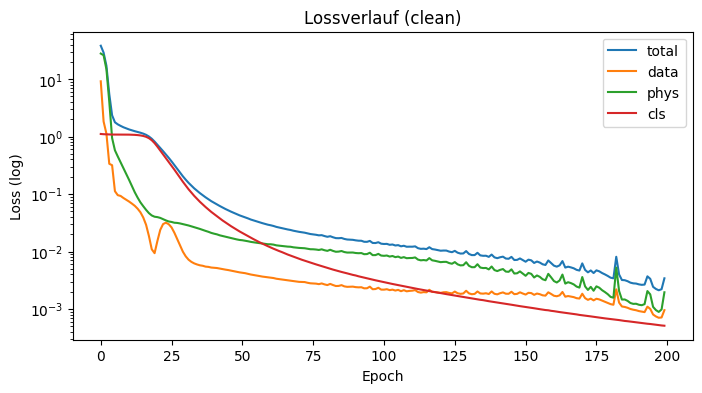

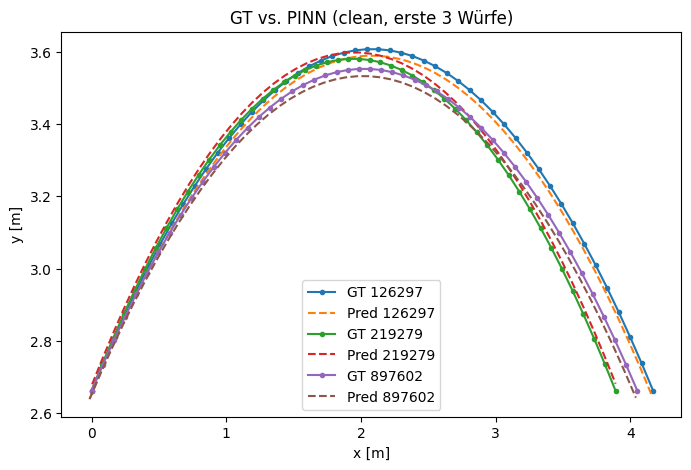

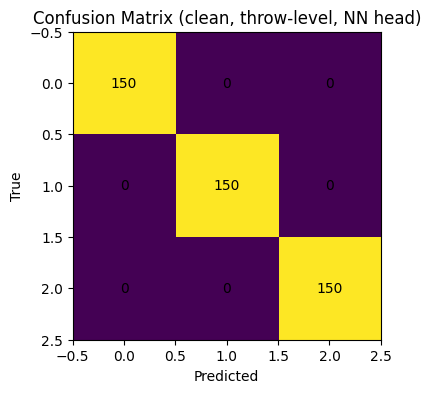

In [ ]:
device='cpu'
sim = DataGen(hs=2.13)
params = sim.params if hasattr(sim,'params') else {'l':4.115,'hKorb':3.048,'Rr':0.2286,'Rb':0.1219}
df_clean = sim.generate_dataset(n=150, with_noise=False)
model_clean = FreeThrowPINNModel(hidden_dim=64, n_classes=3).to(device)
model_clean, hist_clean, dproc_clean = train_pinn(model_clean, df_clean, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1.0, lambda_phys=1.0, lambda_cls=1.0, device=device)

plt.figure(figsize=(8,4))
plt.plot(hist_clean['loss'], label='total')
plt.plot(hist_clean['data_loss'], label='data')
plt.plot(hist_clean['phys_loss'], label='phys')
plt.plot(hist_clean['cls_loss'], label='cls')   # NEW
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log)')
plt.legend()
plt.title('Lossverlauf (clean)')


pred_clean = predict_xy(model_clean, dproc_clean)
ids = pred_clean["wurf_id"].unique()[:3]
plt.figure(figsize=(8, 5))
for wid in ids:
    g_gt = dproc_clean[dproc_clean["wurf_id"] == wid].sort_values("t")
    g_pr = pred_clean[pred_clean["wurf_id"] == wid].sort_values("t")
    plt.plot(g_gt["x"], g_gt["y"], marker=".", label=f"GT {wid[:6]}")
    plt.plot(g_pr["x_pred"], g_pr["y_pred"], linestyle="--", label=f"Pred {wid[:6]}")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("GT vs. PINN (clean, erste 3 Würfe)")
plt.legend()

# NEW: use end-to-end NN classifier
eval_clean = evaluate_throw_level_nn(dproc_clean, model_clean, device=device)

print("Clean throw-level metrics (NN head):")
print(
    "Accuracy=",
    eval_clean["acc"],
    " Precision=",
    eval_clean["prec"],
    " Recall=",
    eval_clean["rec"],
    " F1=",
    eval_clean["f1"],
)

cm = eval_clean["cm"]
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix (clean, throw-level, NN head)")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

## Noisy‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=36.255783 (data=7.343779, phys=27.809582, cls=1.102422)
Epoch 002 | loss=27.296872 (data=1.678868, phys=24.517731, cls=1.100272)
Epoch 003 | loss=12.693331 (data=0.874376, phys=10.722851, cls=1.096105)
Epoch 004 | loss=4.304883 (data=0.429996, phys=2.782941, cls=1.091945)
Epoch 005 | loss=2.012313 (data=0.263839, phys=0.660459, cls=1.088015)
Epoch 020 | loss=0.630971 (data=0.046456, phys=0.039583, cls=0.544932)
Epoch 040 | loss=0.079951 (data=0.023740, phys=0.019286, cls=0.036925)
Epoch 060 | loss=0.045257 (data=0.022798, phys=0.011838, cls=0.010620)
Epoch 080 | loss=0.035986 (data=0.022302, phys=0.008989, cls=0.004694)
Epoch 100 | loss=0.032104 (data=0.022203, phys=0.007274, cls=0.002627)
Epoch 120 | loss=0.029798 (data=0.022268, phys=0.005845, cls=0.001684)
Epoch 140 | loss=0.027487 (data=0.022160, phys=0.004191, cls=0.001136)
Epoch 160 | loss=0.026430 (data=0.022114, phys=0.003515, cls=0.000802)
Epoch 180 | loss=0.024765 (data=0.021681, phys=0.002490, cls=0.000595)


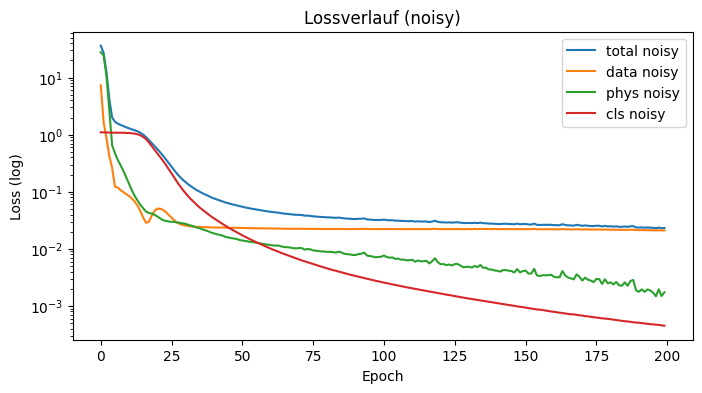

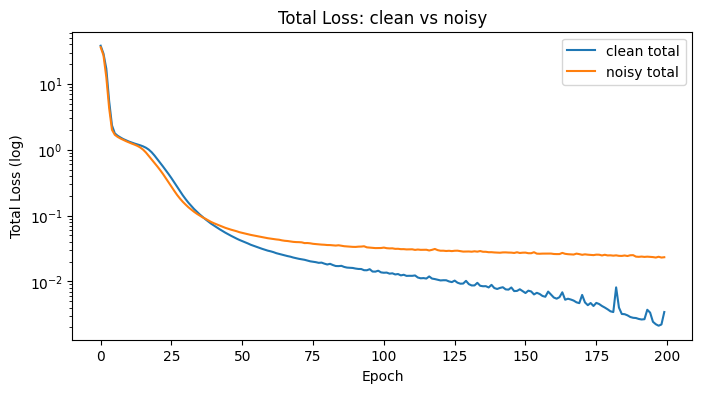

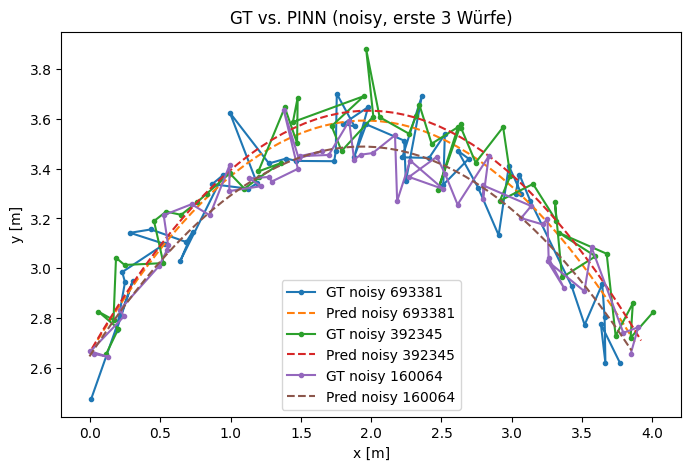

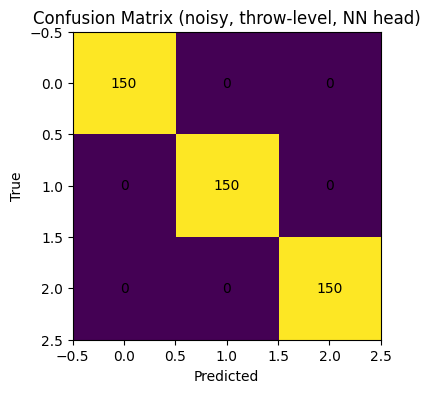

In [41]:
# --- Noisy training with end-to-end PINN + classification head ---

df_noisy = sim.generate_dataset(n=150, with_noise=True)

# note: n_classes=3 and lambda_cls added
model_noisy = FreeThrowPINNModel(hidden_dim=64, n_classes=3).to(device)
model_noisy, hist_noisy, dproc_noisy = train_pinn(
    model_noisy,
    df_noisy,
    n_epochs=200,
    batch_size=1024,
    lr=1e-3,
    lambda_data=1,
    lambda_phys=1,
    lambda_cls=1,  # <--- NEW: classification loss weight
    device=device,
)

# Loss curves (now also showing classification loss)
plt.figure(figsize=(8, 4))
plt.plot(hist_noisy["loss"], label="total noisy")
plt.plot(hist_noisy["data_loss"], label="data noisy")
plt.plot(hist_noisy["phys_loss"], label="phys noisy")
plt.plot(hist_noisy["cls_loss"], label="cls noisy")  # <--- NEW
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.legend()
plt.title("Lossverlauf (noisy)")

# Total loss comparison clean vs noisy (unchanged except for hist structure)
plt.figure(figsize=(8, 4))
plt.plot(hist_clean["loss"], label="clean total")
plt.plot(hist_noisy["loss"], label="noisy total")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (log)")
plt.legend()
plt.title("Total Loss: clean vs noisy")

# Trajectory plots (same as before, predict_xy already updated to ignore logits)
pred_noisy = predict_xy(model_noisy, dproc_noisy)
ids2 = pred_noisy["wurf_id"].unique()[:3]
plt.figure(figsize=(8, 5))
for wid in ids2:
    g_gt = dproc_noisy[dproc_noisy["wurf_id"] == wid].sort_values("t")
    g_pr = pred_noisy[pred_noisy["wurf_id"] == wid].sort_values("t")
    plt.plot(g_gt["x"], g_gt["y"], marker=".", label=f"GT noisy {wid[:6]}")
    plt.plot(
        g_pr["x_pred"], g_pr["y_pred"], linestyle="--", label=f"Pred noisy {wid[:6]}"
    )
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("GT vs. PINN (noisy, erste 3 Würfe)")
plt.legend()

# --- throw-level evaluation now via NN classification head ---
# (uses the same evaluate_throw_level_nn helper as for the clean case)

eval_noisy = evaluate_throw_level_nn(dproc_noisy, model_noisy, device=device)

print("Noisy throw-level metrics (NN head):")
print(
    "Accuracy=",
    eval_noisy["acc"],
    " Precision=",
    eval_noisy["prec"],
    " Recall=",
    eval_noisy["rec"],
    " F1=",
    eval_noisy["f1"],
)

cmn = eval_noisy["cm"]
plt.figure(figsize=(5, 4))
plt.imshow(cmn)
plt.title("Confusion Matrix (noisy, throw-level, NN head)")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i, j], ha="center", va="center")

# Comparison clean vs noisy (both from NN head now)
comp = pd.DataFrame(
    [
        {
            "set": "clean",
            "acc": eval_clean["acc"],
            "prec": eval_clean["prec"],
            "rec": eval_clean["rec"],
            "f1": eval_clean["f1"],
        },
        {
            "set": "noisy",
            "acc": eval_noisy["acc"],
            "prec": eval_noisy["prec"],
            "rec": eval_noisy["rec"],
            "f1": eval_noisy["f1"],
        },
    ]
)
print("Vergleich (wurf-level, NN head):")
print(comp)

In [42]:
# Split-Logik: erste 30 Punkte vs. volle 50 Punkte pro Wurf ===============================

from typing import Tuple, Dict


def add_point_index(df: pd.DataFrame) -> pd.DataFrame:
    """Fügt pro wurf_id einen 1-basierten Punktindex hinzu (nach Zeit sortiert)."""
    assert "wurf_id" in df.columns, "Erwarte Spalte 'wurf_id'."
    # Sortierung: falls 't' existiert, danach sortieren; sonst x/vx Heuristik vermeiden -> fallback: index
    if "t" in df.columns:
        df = df.sort_values(["wurf_id", "t"]).copy()
    else:
        df = df.sort_values(["wurf_id"]).copy()
    df["point_idx"] = df.groupby("wurf_id").cumcount() + 1
    return df


def split_first30_full50(
    df: pd.DataFrame, first_n: int = 30
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (df_train30, df_full50) zurück.
    df_train30 enthält nur die ersten N Punkte pro Wurf.
    df_full50 enthält alle verfügbaren Punkte (typisch 50).
    """
    dfi = add_point_index(df)
    df_train30 = dfi[dfi["point_idx"] <= first_n].copy()
    df_full50 = dfi.copy()
    return df_train30, df_full50

In [43]:
# Metriken In-Domain (1–30) vs. Out-of-Domain (31–50) ====================================


def mse_mae(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    mse = float(np.mean((y_true - y_pred) ** 2)) if len(y_true) > 0 else np.nan
    mae = float(np.mean(np.abs(y_true - y_pred))) if len(y_true) > 0 else np.nan
    return {"mse": mse, "mae": mae}


def evaluate_in_out_domain(pred_df: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    """
    Erwartet Spalten: x, y, x_pred, y_pred, point_idx.
    Gibt MSE/MAE getrennt für 1–30, 31–50 und 1–50 zurück (sowohl für x als auch y).
    """
    required = {"x", "y", "x_pred", "y_pred", "point_idx"}
    missing = required - set(pred_df.columns)
    assert not missing, f"Fehlende Spalten: {missing}"

    df = pred_df.copy()
    in_mask = df["point_idx"] <= 30
    out_mask = df["point_idx"] > 30

    res = {
        "x_in": mse_mae(
            df.loc[in_mask, "x"].to_numpy(), df.loc[in_mask, "x_pred"].to_numpy()
        ),
        "x_out": mse_mae(
            df.loc[out_mask, "x"].to_numpy(), df.loc[out_mask, "x_pred"].to_numpy()
        ),
        "x_all": mse_mae(df["x"].to_numpy(), df["x_pred"].to_numpy()),
        "y_in": mse_mae(
            df.loc[in_mask, "y"].to_numpy(), df.loc[in_mask, "y_pred"].to_numpy()
        ),
        "y_out": mse_mae(
            df.loc[out_mask, "y"].to_numpy(), df.loc[out_mask, "y_pred"].to_numpy()
        ),
        "y_all": mse_mae(df["y"].to_numpy(), df["y_pred"].to_numpy()),
    }
    return res

In [44]:
# Visualisierung: GT vs. Pred (1–50) mit Markierung bei Punkt 30 ==========================

import matplotlib.pyplot as plt


def plot_trajectories_with_cutoff(
    pred_full50_df: pd.DataFrame, wurf_ids=None, max_plots: int = 3
):
    """
    Plottet für ausgewählte Würfe die GT- und Pred-Trajektorie (x,y) und markiert den Cutoff bei point_idx=30.
    """
    if wurf_ids is None:
        wurf_ids = list(pred_full50_df["wurf_id"].unique())[:max_plots]

    for wid in wurf_ids[:max_plots]:
        dfw = pred_full50_df[pred_full50_df["wurf_id"] == wid].sort_values("point_idx")
        cutoff_x = (
            dfw.loc[dfw["point_idx"] == 30, "x"].iloc[0]
            if (dfw["point_idx"] == 30).any()
            else None
        )

        plt.figure(figsize=(5.5, 4.5))
        plt.plot(dfw["x"], dfw["y"], label="GT")
        plt.plot(dfw["x_pred"], dfw["y_pred"], label="Pred")
        if cutoff_x is not None:
            plt.axvline(cutoff_x, linestyle="--", label="Cutoff @ 30")
        plt.title(f"Wurf {wid}: GT vs. Pred (1–50)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.tight_layout()
        plt.show()

Epoch 001 | loss=36.759543 (data=8.696314, phys=26.955607, cls=1.107622)
Epoch 002 | loss=28.405682 (data=1.174440, phys=26.128104, cls=1.103138)
Epoch 003 | loss=23.845299 (data=0.715207, phys=22.030629, cls=1.099463)
Epoch 004 | loss=13.029933 (data=0.910912, phys=11.016608, cls=1.102414)
Epoch 005 | loss=5.901702 (data=0.256879, phys=4.541970, cls=1.102853)
Epoch 020 | loss=1.234828 (data=0.050441, phys=0.107865, cls=1.076522)
Epoch 040 | loss=0.373713 (data=0.022631, phys=0.031068, cls=0.320015)
Epoch 060 | loss=0.084832 (data=0.002590, phys=0.020631, cls=0.061611)
Epoch 080 | loss=0.039013 (data=0.001736, phys=0.014223, cls=0.023054)
Epoch 100 | loss=0.023829 (data=0.001324, phys=0.010361, cls=0.012145)
Epoch 120 | loss=0.016335 (data=0.001038, phys=0.007963, cls=0.007334)
Epoch 140 | loss=0.011818 (data=0.000838, phys=0.006158, cls=0.004821)
Epoch 160 | loss=0.009177 (data=0.000777, phys=0.005004, cls=0.003395)
Epoch 180 | loss=0.007709 (data=0.000828, phys=0.004361, cls=0.002521

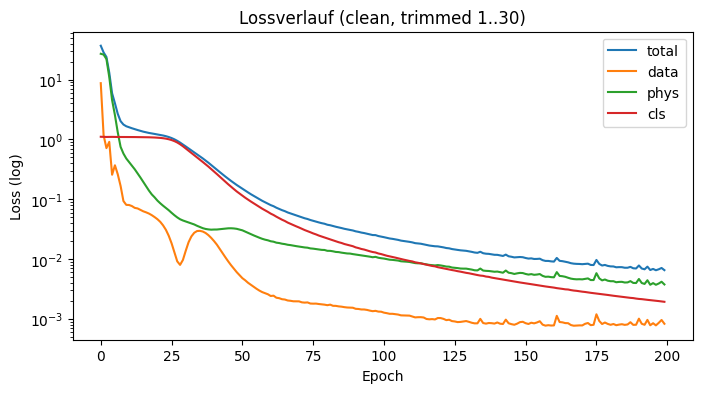

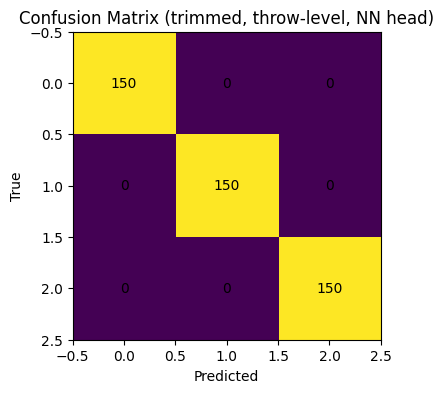

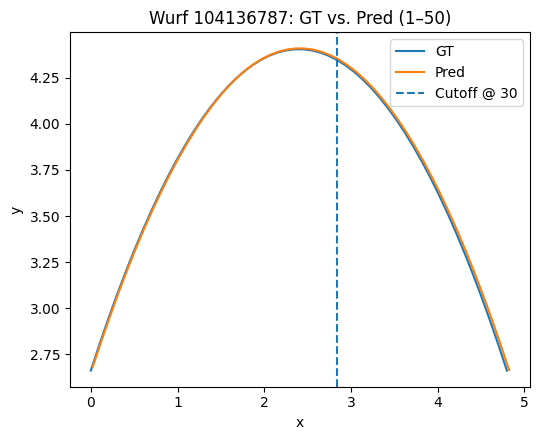

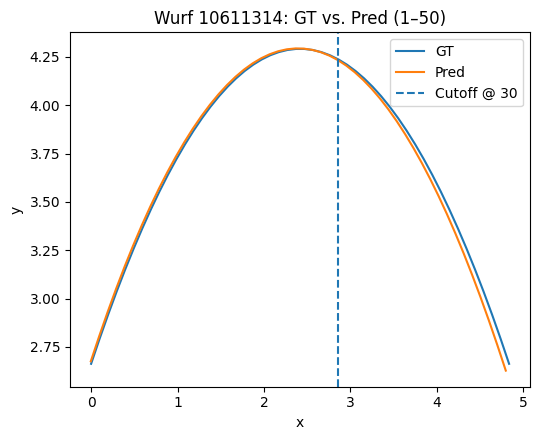

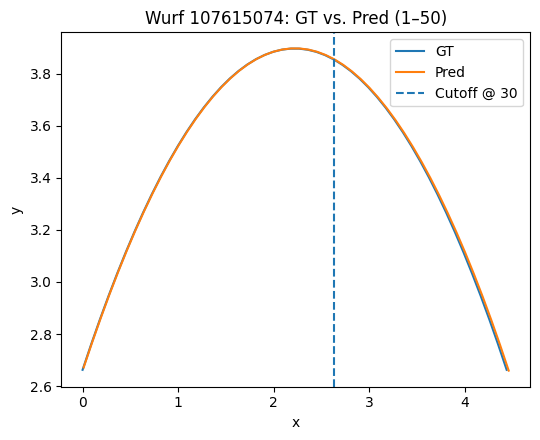

In [45]:
# === CLEAN RUN (trimmed: train auf 1..30, predict 1..50) ================================

# 1) Daten splitten
device = "cpu"
sim = DataGen(hs=2.13)
params = (
    sim.params
    if hasattr(sim, "params")
    else {"l": 4.115, "hKorb": 3.048, "Rr": 0.2286, "Rb": 0.1219}
)

df_clean2 = sim.generate_dataset(n=150, with_noise=False)
df_train30_clean, df_full50_clean = split_first30_full50(df_clean2, first_n=30)

# 2) Modell initialisieren (mit Klassifikations-Head)
model_clean2 = FreeThrowPINNModel(hidden_dim=64, n_classes=3).to(device)

# 3) Training nur auf den ersten 30 Punkten pro Wurf
model_clean2, hist_clean_trim, dproc_train30_clean = train_pinn(
    model_clean2,
    df_train30_clean,
    n_epochs=200,
    batch_size=1024,
    lr=1e-3,
    lambda_data=1.0,
    lambda_phys=1.0,
    lambda_cls=1.0,  # wichtig für Klassifikations-Loss
    n_collocation_per_sample=5,
    df_for_tmax=df_full50_clean,
    device=device,
)

# optional: Lossverlauf inkl. cls_loss plotten
plt.figure(figsize=(8, 4))
plt.plot(hist_clean_trim["loss"], label="total")
plt.plot(hist_clean_trim["data_loss"], label="data")
plt.plot(hist_clean_trim["phys_loss"], label="phys")
plt.plot(hist_clean_trim["cls_loss"], label="cls")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.legend()
plt.title("Lossverlauf (clean, trimmed 1..30)")

# 4) Vorhersage für ALLE 1–50 Punkte
pred_full50_clean = predict_xy(model_clean2, df_full50_clean)

# 5) Metriken In-Domain (1..30) vs. Extrapolation (31..50)
metrics_clean = evaluate_in_out_domain(pred_full50_clean)
metrics_clean  # z.B. in Notebook anzeigen

# 6) Wurf-level Metrik nun über NN-Kopf, nicht mehr deterministisches Regelwerk
eval_throw_clean = evaluate_throw_level_nn(df_full50_clean, model_clean2, device=device)

print("Trimmed throw-level metrics (NN head):")
print(
    "Accuracy=",
    eval_throw_clean["acc"],
    " Precision=",
    eval_throw_clean["prec"],
    " Recall=",
    eval_throw_clean["rec"],
    " F1=",
    eval_throw_clean["f1"],
)

cmn = eval_throw_clean["cm"]
plt.figure(figsize=(5, 4))
plt.imshow(cmn)
plt.title("Confusion Matrix (trimmed, throw-level, NN head)")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i, j], ha="center", va="center")

print("CLEAN — Beispiele")
plot_trajectories_with_cutoff(pred_full50_clean, max_plots=3)